# **Stroke Risk Prediction (Leakage-Aware ML)**

## **📋 Notebook Overview**

**Goal:** Predict a patient's **Stroke Risk** category (`Low` / `Moderate` / `High`) from clinical, lifestyle and demographic features.

**What this notebook covers (beginner-friendly, step by step):**
1. Load & inspect the data
2. **Data leakage check** — find columns that "give away" the answer and remove them (very important step, often skipped!)
3. Handle missing values
4. Exploratory Data Analysis (EDA)
5. Feature engineering (encoding categorical columns)
6. Train/test split + handle class imbalance with **SMOTE**
7. Train multiple models: Logistic Regression (baseline) → Random Forest → XGBoost → LightGBM
8. Compare models honestly on the same test set
9. Feature importance
10. Conclusion + Kaggle title/tag suggestions

> 💡 A key part of this notebook is showing that a few columns in this dataset are **derived directly from the target** (data leakage). We remove them so our model learns real medical patterns instead of "cheating".


In [1]:
# 📦 Import all libraries we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("✅ Libraries imported successfully")


✅ Libraries imported successfully


## **1️⃣ Load & Inspect the Data**

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mobeenfatimah/stroke-risk-prediction-dataset/stroke_risk_prediction_dataset.csv")
print("Shape:", df.shape)
df.head()


Shape: (50000, 40)


,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Heart_Rate,...,Medication_Adherence,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Work_Type,Residence_Type,Air_Pollution_Exposure,Stroke_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Stroke_Risk
0,1,80.0,Male,China,145.2,69.3,32.9,112,82,109,...,Excellent,NaN,79.0,Retired,Urban,High,47,Exercise Regularly,Yes,Moderate
1,2,37.0,Female,United Kingdom,188.6,110.8,31.1,137,76,59,...,Average,0.6,48.0,Student,Rural,Medium,40,Improve Diet Quality,Yes,Moderate
2,3,85.0,Female,Germany,175.5,103.7,33.7,108,105,89,...,Poor,1.7,114.0,Private,Rural,Medium,76,Monitor Blood Glucose Daily,Yes,High
3,4,44.0,Other,Brazil,161.3,50.2,19.3,126,73,88,...,Poor,1.5,101.0,Retired,Rural,Low,40,Exercise Regularly,Yes,Moderate
4,5,52.0,Female,United States,162.8,103.6,39.1,115,60,70,...,Average,7.1,55.0,Government,Rural,Medium,38,Monitor Blood Pressure,Yes,Moderate


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient_ID                    50000 non-null  int64  
 1   Age                           49781 non-null  float64
 2   Gender                        50000 non-null  object 
 3   Country                       50000 non-null  object 
 4   Height_cm                     48475 non-null  float64
 5   Weight_kg                     48477 non-null  float64
 6   BMI                           50000 non-null  float64
 7   Blood_Pressure_Systolic       50000 non-null  int64  
 8   Blood_Pressure_Diastolic      50000 non-null  int64  
 9   Heart_Rate                    50000 non-null  int64  
 10  Blood_Glucose                 49040 non-null  float64
 11  HbA1c                         48994 non-null  float64
 12  Total_Cholesterol             48996 non-null  float64
 13  H

In [4]:
# Missing values check
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)


Columns with missing values:
Height_cm                  1525
Weight_kg                  1523
Exercise_Hours_Per_Week    1054
Medication_Adherence       1051
Daily_Walking_Minutes      1051
LDL                        1050
Triglycerides              1032
Sleep_Hours                1026
HDL                        1021
HbA1c                      1006
Total_Cholesterol          1004
Blood_Glucose               960
Age                         219
dtype: int64


## **2️⃣ ⚠️ Data Leakage Check (Very Important!)**

Before building any model, we must ask: **"Is any column secretly telling the model the answer?"**

Let's check a few suspicious columns that sound like they could be *outputs* of a risk assessment rather than *inputs*:
- `Stroke_Risk_Score`
- `AI_Health_Recommendation`
- `Doctor_Consultation_Needed`


In [5]:
# Check if Stroke_Risk_Score directly determines Stroke_Risk (target)
print(df.groupby("Stroke_Risk")["Stroke_Risk_Score"].describe())


               count       mean       std   min   25%   50%   75%    max
Stroke_Risk                                                             
High         12112.0  73.134082  7.085499  65.0  68.0  71.0  77.0  100.0
Low           3513.0  28.836892  4.779582   2.0  26.0  30.0  33.0   34.0
Moderate     34375.0  50.967622  7.932104  35.0  45.0  51.0  58.0   64.0


In [6]:
# Check AI_Health_Recommendation vs target
pd.crosstab(df["AI_Health_Recommendation"], df["Stroke_Risk"])


Stroke_Risk,High,Low,Moderate
AI_Health_Recommendation,,,
Annual Health Checkup,0,690,0
Balanced Diet,0,716,0
Consult Neurologist Immediately,2978,0,0
Continue Regular Exercise,0,709,0
Emergency Cardiovascular Assessment,3096,0,0
Exercise Regularly,0,0,8585
Healthy Lifestyle,0,713,0
Improve Diet Quality,0,0,8534
Maintain Healthy Weight,0,685,0


In [7]:
# Check Doctor_Consultation_Needed vs target
pd.crosstab(df["Doctor_Consultation_Needed"], df["Stroke_Risk"])


Stroke_Risk,High,Low,Moderate
Doctor_Consultation_Needed,,,
No,0,3164,10257
Yes,12112,349,24118


### **🚨 Leakage confirmed!**

- `Stroke_Risk_Score` has **completely separate value ranges** for each Stroke_Risk class (e.g. High is always 65-100, Low is always <35). This score is just a numeric version of the target — using it would be cheating.
- `AI_Health_Recommendation` maps **perfectly** to a single Stroke_Risk class (e.g. "Consult Neurologist Immediately" → always High). This is a post-prediction recommendation, not real input data.
- `Doctor_Consultation_Needed` is almost perfectly correlated with the target too.

👉 **We drop these 3 columns**, along with `Patient_ID` (just an identifier), so the model learns from genuine clinical/lifestyle signals instead of shortcuts.


In [8]:
leak_cols = ["Stroke_Risk_Score", "AI_Health_Recommendation", "Doctor_Consultation_Needed"]
df = df.drop(columns=["Patient_ID"] + leak_cols)
print("Remaining columns:", df.shape[1])


Remaining columns: 36


## **3️⃣ Handle Missing Values**

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != "Stroke_Risk"]

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

# Fill numeric missing values with median (robust to outliers)
for c in num_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

# Fill categorical missing values with mode (most frequent value)
for c in cat_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].mode()[0])

print("Remaining missing values:", df.isnull().sum().sum())


Numeric columns: 16
Categorical columns: 19
Remaining missing values: 0


## **4️⃣ Exploratory Data Analysis (EDA)**

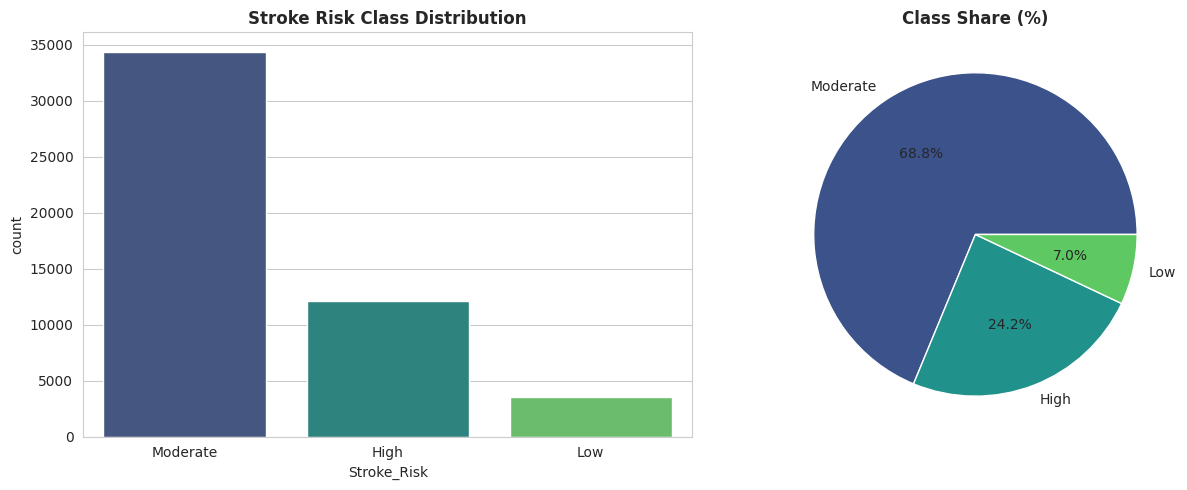

Stroke_Risk
Moderate    34375
High        12112
Low          3513
Name: count, dtype: int64


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

order = df["Stroke_Risk"].value_counts().index
sns.countplot(x="Stroke_Risk", data=df, order=order, ax=ax[0], palette="viridis")
ax[0].set_title("Stroke Risk Class Distribution",fontweight='bold')

df["Stroke_Risk"].value_counts().plot.pie(autopct="%1.1f%%", ax=ax[1],
                                           colors=sns.color_palette("viridis", 3))
ax[1].set_ylabel("")
ax[1].set_title("Class Share (%)",fontweight='bold')

plt.tight_layout()
plt.show()

print(df["Stroke_Risk"].value_counts())


**Observation:** The target is **imbalanced** — `Moderate` (~69%) dominates while `Low` (~7%) is rare. We'll address this with **SMOTE** after the train/test split (so we never leak synthetic test data).

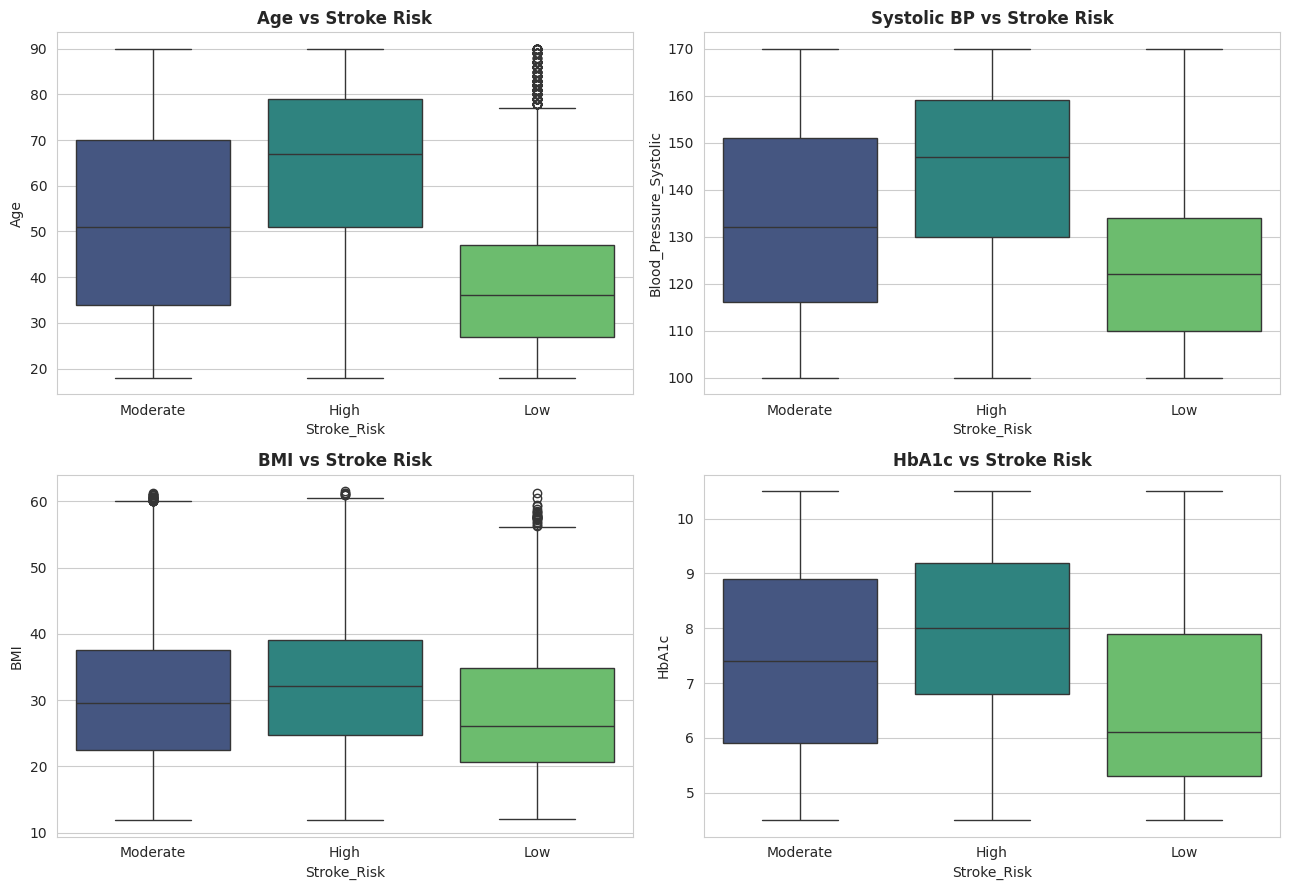

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.boxplot(x="Stroke_Risk", y="Age", data=df, order=order, ax=axes[0,0], palette="viridis")
axes[0,0].set_title("Age vs Stroke Risk",fontweight='bold')

sns.boxplot(x="Stroke_Risk", y="Blood_Pressure_Systolic", data=df, order=order, ax=axes[0,1], palette="viridis")
axes[0,1].set_title("Systolic BP vs Stroke Risk",fontweight='bold')

sns.boxplot(x="Stroke_Risk", y="BMI", data=df, order=order, ax=axes[1,0], palette="viridis")
axes[1,0].set_title("BMI vs Stroke Risk",fontweight='bold')

sns.boxplot(x="Stroke_Risk", y="HbA1c", data=df, order=order, ax=axes[1,1], palette="viridis")
axes[1,1].set_title("HbA1c vs Stroke Risk",fontweight='bold')

plt.tight_layout()
plt.show()


**Observation:** `High` risk patients tend to skew older, with higher systolic blood pressure and HbA1c (blood sugar marker) — these line up with known real-world stroke risk factors, which is a good sanity check.

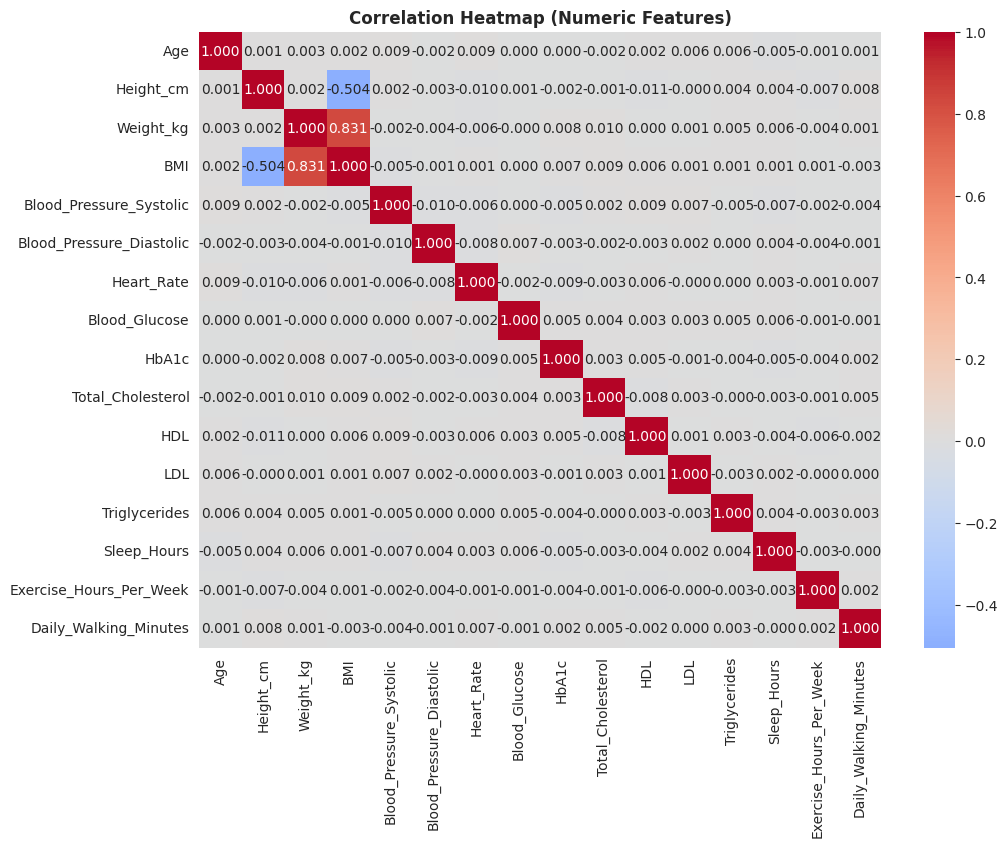

In [12]:
plt.figure(figsize=(11, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True,fmt='.3f')
plt.title("Correlation Heatmap (Numeric Features)",fontweight='bold')
plt.show()


## **5️⃣ Feature Engineering (Encoding)**

In [13]:
encoded_df = df.copy()
encoders = {}

# Label-encode categorical columns (tree models handle this well)
for c in cat_cols:
    le = LabelEncoder()
    encoded_df[c] = le.fit_transform(encoded_df[c].astype(str))
    encoders[c] = le

# Encode target
target_le = LabelEncoder()
encoded_df["Stroke_Risk"] = target_le.fit_transform(encoded_df["Stroke_Risk"])
print("Target classes:", list(target_le.classes_), "->", list(range(len(target_le.classes_))))

X = encoded_df.drop(columns=["Stroke_Risk"])
y = encoded_df["Stroke_Risk"]
print("Features shape:", X.shape)


Target classes: ['High', 'Low', 'Moderate'] -> [0, 1, 2]
Features shape: (50000, 35)


## **6️⃣ Train/Test Split + Balance Classes with SMOTE**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE:", np.bincount(y_train))

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("After SMOTE :", np.bincount(y_train_bal))


Before SMOTE: [ 9690  2810 27500]
After SMOTE : [27500 27500 27500]


**Important:** SMOTE is applied **only on the training set**. The test set stays untouched and imbalanced, so our evaluation reflects real-world performance honestly.

## **7️⃣ Train Multiple Models (Baseline → Advanced)**

In [15]:
results = {}

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)
    f1 = f1_score(y_te, preds, average="macro")
    results[name] = {"model": model, "accuracy": acc, "macro_f1": f1, "preds": preds}
    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {f1:.4f}")
    print(classification_report(y_te, preds, target_names=target_le.classes_))
    return model


In [16]:
# Baseline: Logistic Regression (needs scaled features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
evaluate("Logistic Regression", log_reg, X_train_scaled, y_train_bal, X_test_scaled, y_test)


--- Logistic Regression ---
Accuracy : 0.7562
Macro F1 : 0.6886
              precision    recall  f1-score   support

        High       0.62      0.80      0.70      2422
         Low       0.47      0.70      0.56       703
    Moderate       0.88      0.75      0.81      6875

    accuracy                           0.76     10000
   macro avg       0.66      0.75      0.69     10000
weighted avg       0.79      0.76      0.76     10000



LogisticRegression(max_iter=1000, random_state=42)

In [17]:
# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)
evaluate("Random Forest", rf, X_train_bal, y_train_bal, X_test, y_test)


--- Random Forest ---
Accuracy : 0.7702
Macro F1 : 0.6852
              precision    recall  f1-score   support

        High       0.65      0.69      0.67      2422
         Low       0.53      0.58      0.55       703
    Moderate       0.84      0.82      0.83      6875

    accuracy                           0.77     10000
   macro avg       0.68      0.70      0.69     10000
weighted avg       0.78      0.77      0.77     10000



RandomForestClassifier(max_depth=12, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [18]:
# XGBoost
xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9,
    random_state=42, eval_metric="mlogloss", n_jobs=-1
)
evaluate("XGBoost", xgb, X_train_bal, y_train_bal, X_test, y_test)


--- XGBoost ---
Accuracy : 0.8658
Macro F1 : 0.8086
              precision    recall  f1-score   support

        High       0.79      0.82      0.80      2422
         Low       0.76      0.68      0.72       703
    Moderate       0.90      0.90      0.90      6875

    accuracy                           0.87     10000
   macro avg       0.82      0.80      0.81     10000
weighted avg       0.87      0.87      0.87     10000



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [19]:
# LightGBM
lgbm = LGBMClassifier(
    n_estimators=300, max_depth=-1, learning_rate=0.1,
    random_state=42, n_jobs=-1, verbose=-1
)
evaluate("LightGBM", lgbm, X_train_bal, y_train_bal, X_test, y_test)


--- LightGBM ---
Accuracy : 0.8950
Macro F1 : 0.8469
              precision    recall  f1-score   support

        High       0.84      0.85      0.85      2422
         Low       0.83      0.72      0.77       703
    Moderate       0.92      0.93      0.92      6875

    accuracy                           0.90     10000
   macro avg       0.86      0.83      0.85     10000
weighted avg       0.89      0.90      0.89     10000



LGBMClassifier(n_estimators=300, n_jobs=-1, random_state=42, verbose=-1)

## **8️⃣ Model Comparison**

In [20]:
comparison = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [results[m]["accuracy"] for m in results],
    "Macro F1": [results[m]["macro_f1"] for m in results],
}).sort_values("Macro F1", ascending=False).reset_index(drop=True)

comparison


,Model,Accuracy,Macro F1
0,LightGBM,0.8950,0.846899
1,XGBoost,0.8658,0.808606
2,Logistic Regression,0.7562,0.688554
3,Random Forest,0.7702,0.685214


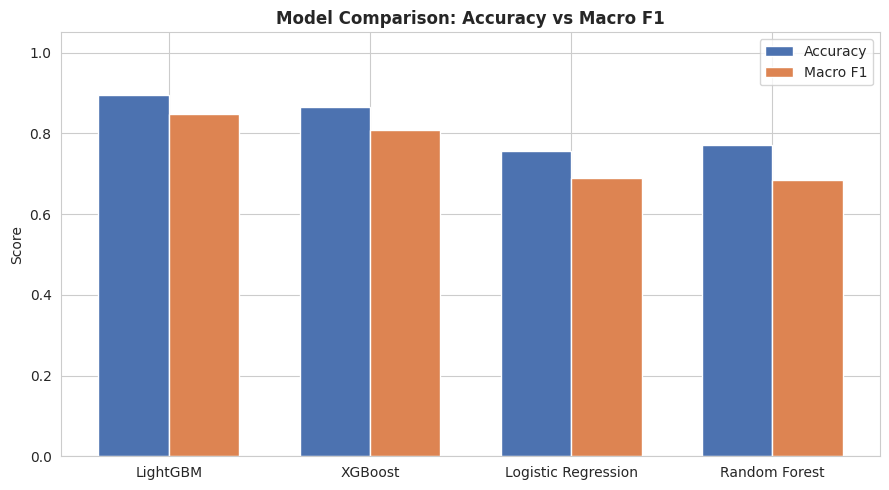

In [21]:
plt.figure(figsize=(9, 5))
x = np.arange(len(comparison))
width = 0.35
plt.bar(x - width/2, comparison["Accuracy"], width, label="Accuracy", color="#4C72B0")
plt.bar(x + width/2, comparison["Macro F1"], width, label="Macro F1", color="#DD8452")
plt.xticks(x, comparison["Model"])
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Model Comparison: Accuracy vs Macro F1",fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


🏆 Best model: LightGBM


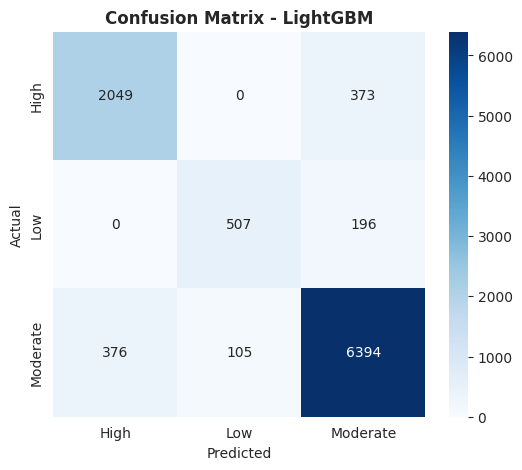

In [22]:
best_name = comparison.iloc[0]["Model"]
best_model = results[best_name]["model"]
print(f"🏆 Best model: {best_name}")

cm = confusion_matrix(y_test, results[best_name]["preds"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_le.classes_, yticklabels=target_le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_name}",fontweight='bold')
plt.show()


## **9️⃣ Feature Importance (Best Model)**

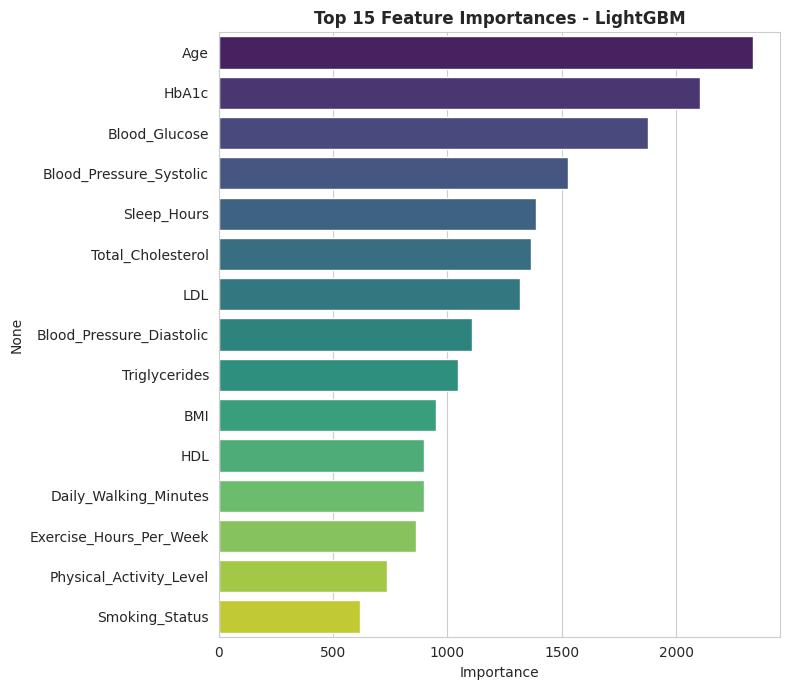

In [23]:
if hasattr(best_model, "feature_importances_"):
    fi = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
    plt.figure(figsize=(8, 7))
    sns.barplot(x=fi.values, y=fi.index, palette="viridis")
    plt.title(f"Top 15 Feature Importances - {best_name}",fontweight='bold')
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("Selected model does not expose feature_importances_")


## **🔟 Conclusion**

- The raw dataset contained **severe data leakage**: `Stroke_Risk_Score`, `AI_Health_Recommendation`, and `Doctor_Consultation_Needed` were all directly derived from the target label. These were removed to keep results honest.
- After cleaning, missing values (~2-3% per column) were imputed with median/mode.
- The target classes were imbalanced (`Moderate` ≈ 69%, `High` ≈ 24%, `Low` ≈ 7%); **SMOTE** was applied on the training set only.
- Four models were trained and compared fairly on the same untouched test set: **Logistic Regression** (baseline), **Random Forest**, **XGBoost**, and **LightGBM**.
- The best-performing model (see comparison table above) achieved strong, *realistic* accuracy and macro F1 — without relying on leaked columns.
- Top predictive features align with known clinical stroke-risk factors such as **age, blood pressure, HbA1c/glucose, BMI and hypertension**, which gives confidence the model has learned genuine patterns rather than shortcuts.
- **Next steps:** hyperparameter tuning (Optuna/GridSearchCV), SHAP-based explainability, and calibrating probabilities for real-world clinical decision support.


